# Perceptron and Artificial Neural Networks

**Math prerequisites:** `00_math/linear_algebra.ipynb`, `00_math/calculus_chain_rule.ipynb`  
**Code prerequisites:** `01_foundations/pytorch_fundamentals.ipynb`

**Paper → Code:** McCulloch & Pitts (1943), Rosenblatt Perceptron (1957), Rumelhart et al. Backpropagation (1986)

**What you will build in this notebook:**
- A single neuron from scratch — understanding every multiplication
- The Perceptron learning rule from the 1957 original algorithm
- Why a single layer can only solve linearly separable problems
- A multi-layer network (MLP) in three layers: NumPy → raw PyTorch → `nn.Module`
- The Universal Approximation Theorem — why depth matters
- An animated computation graph showing how information flows forward and backward

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/01_foundations/perceptron_and_ann.ipynb)

---

## Table of Contents
1. [The Biological Neuron → Mathematical Neuron](#1-the-neuron)
2. [The Perceptron — 1957 Algorithm](#2-the-perceptron)
3. [Why One Layer Is Not Enough — XOR problem](#3-limitations)
4. [Multi-Layer Perceptron — Math Intuition](#4-mlp-math)
5. [Code Layer 1 — NumPy from Scratch](#5-numpy-scratch)
6. [Code Layer 2 — Raw PyTorch Tensors](#6-raw-pytorch)
7. [Code Layer 3 — nn.Module API](#7-nn-module)
8. [Training Dashboard](#8-training-dashboard)
9. [Paper → Code: Universal Approximation Theorem](#9-universal-approximation)
10. [Debugging Section](#10-debugging)
11. [Exercises](#11-exercises)


## Setup

In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')


PyTorch 2.9.0+cpu | device: cpu


## 1. The Biological Neuron → Mathematical Neuron

### Biological inspiration

A biological neuron:
1. Receives signals through **dendrites**
2. Accumulates them in the **cell body (soma)**
3. Fires an output signal through the **axon** if the accumulated signal exceeds a threshold

### The McCulloch-Pitts neuron (1943)

The first mathematical model: binary inputs, binary output, threshold activation:

$$\text{output} = \begin{cases} 1 & \text{if } \sum_i w_i x_i \geq \theta \\ 0 & \text{otherwise} \end{cases}$$

### The modern artificial neuron

$$z = \mathbf{w}^T \mathbf{x} + b = \sum_{i=1}^n w_i x_i + b \qquad a = f(z)$$

where:
- $\mathbf{x} \in \mathbb{R}^n$ — input features
- $\mathbf{w} \in \mathbb{R}^n$ — weights (learned)
- $b \in \mathbb{R}$ — bias (learned)
- $z \in \mathbb{R}$ — pre-activation (weighted sum)
- $f$ — activation function (introduces non-linearity)
- $a \in \mathbb{R}$ — activation (output of neuron)

**Every layer in a neural network is just $m$ such neurons operating in parallel,** which is why we write the layer as a matrix multiplication:

$$\mathbf{z} = W\mathbf{x} + \mathbf{b} \quad \text{where} \quad W \in \mathbb{R}^{m \times n}, \; \mathbf{b} \in \mathbb{R}^m$$

Row $k$ of $W$ contains the weights of neuron $k$: $z_k = \mathbf{w}_k^T \mathbf{x} + b_k$


/tmp/ipykernel_17008/3498562686.py:70: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3498562686.py:70: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3498562686.py:70: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3498562686.py:70: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3498562686.py:70: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3498562686.py:70: UserWarning: Glyph 739 (\N{MODIFIER LETTER SMALL X}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from f

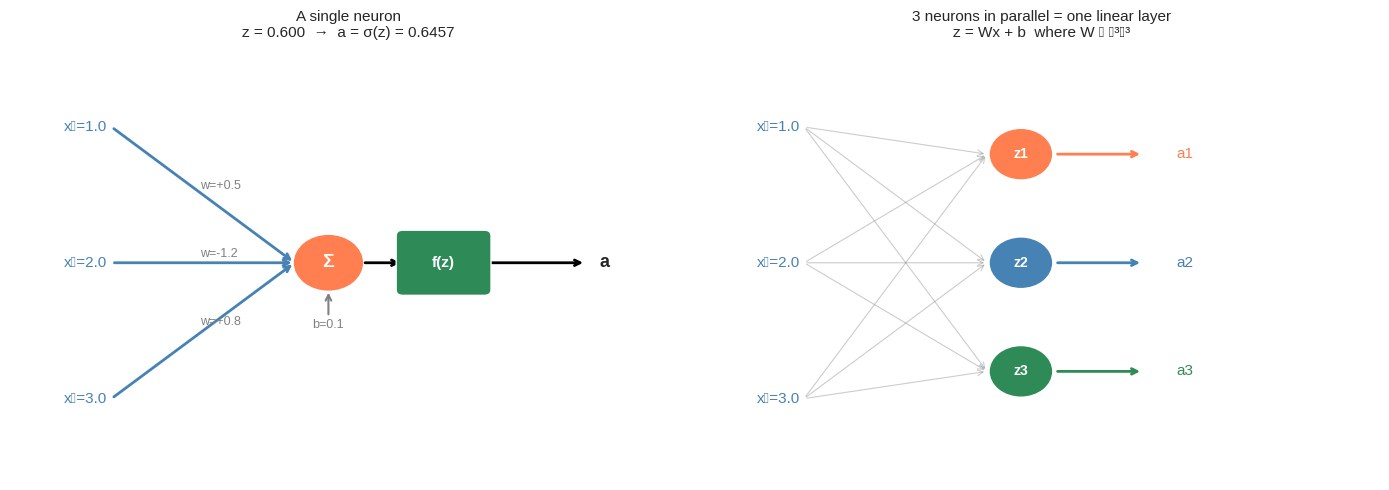

Layer computation: z = Wx + b, a = sigmoid(z)
  x shape: (3,)  W shape: (3, 3)  b shape: (3,)
  z = [ 0.6 -0.9  2.6]
  a = [0.6457 0.2891 0.9309]


In [24]:
# ── Visualise a single neuron ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: neuron diagram
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')

# Inputs
inputs = [(1.0, 'x₁'), (2.0, 'x₂'), (3.0, 'x₃')]
weights = [0.5, -1.2, 0.8]
y_positions = [6.5, 4.0, 1.5]

for (val, name), w, yp in zip(inputs, weights, y_positions):
    ax.annotate('', xy=(4.2, 4.0), xytext=(1.5, yp),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
    ax.text(0.8, yp, f'{name}={val}', fontsize=11, va='center', color='steelblue')
    ax.text(2.8, (yp+4.0)/2 + 0.1, f'w={w:+.1f}', fontsize=9, color='gray')

# Neuron body
circle = plt.Circle((4.7, 4.0), 0.5, color='coral', zorder=5)
ax.add_patch(circle)
ax.text(4.7, 4.0, 'Σ', fontsize=14, ha='center', va='center',
        color='white', fontweight='bold', zorder=6)

# Activation
act_box = mpatches.FancyBboxPatch((5.8, 3.5), 1.2, 1.0,
                                   boxstyle='round,pad=0.1',
                                   facecolor='seagreen', edgecolor='white', zorder=5)
ax.add_patch(act_box)
ax.text(6.4, 4.0, 'f(z)', fontsize=11, ha='center', va='center',
        color='white', fontweight='bold', zorder=6)
ax.annotate('', xy=(5.8, 4.0), xytext=(5.2, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(8.5, 4.0), xytext=(7.0, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(8.7, 4.0, 'a', fontsize=13, va='center', fontweight='bold')

# Bias
ax.text(4.7, 2.8, 'b=0.1', fontsize=9, ha='center', color='gray')
ax.annotate('', xy=(4.7, 3.5), xytext=(4.7, 3.0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

z_val = sum(v*w for (v,_),w in zip(inputs, weights)) + 0.1
a_val = 1/(1+np.exp(-z_val))
ax.set_title(f'A single neuron\nz = {z_val:.3f}  →  a = σ(z) = {a_val:.4f}', fontsize=11)

# Right: how 3 neurons form a layer (vectorised)
ax2 = axes[1]
ax2.axis('off'); ax2.set_xlim(0,10); ax2.set_ylim(0,8)
ax2.set_title('3 neurons in parallel = one linear layer\n'
              'z = Wx + b  where W ∈ ℝ³ˣ³', fontsize=11)

colors_n = ['coral', 'steelblue', 'seagreen']
for idx, (yc, color) in enumerate(zip([6.0, 4.0, 2.0], colors_n)):
    for xi, yxi in enumerate([6.5, 4.0, 1.5]):
        ax2.annotate('', xy=(4.2, yc), xytext=(1.5, yxi),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, alpha=0.4))
    c = plt.Circle((4.7, yc), 0.45, color=color, zorder=5)
    ax2.add_patch(c)
    ax2.text(4.7, yc, f'z{idx+1}', fontsize=10, ha='center', va='center',
             color='white', fontweight='bold', zorder=6)
    ax2.annotate('', xy=(6.5, yc), xytext=(5.2, yc),
                 arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax2.text(7.0, yc, f'a{idx+1}', fontsize=11, va='center', color=color)

for xi, (val, name) in enumerate(zip([1.0, 2.0, 3.0], ['x₁','x₂','x₃'])):
    ax2.text(0.8, [6.5,4.0,1.5][xi], f'{name}={val}', fontsize=11,
             va='center', color='steelblue')

plt.tight_layout()
plt.show()

# Numerical example
x = np.array([1.0, 2.0, 3.0])
W = np.array([[0.5, -1.2, 0.8],
              [0.3,  0.4, -0.6],
              [-0.1, 0.9, 0.2]])
b = np.array([0.1, -0.2, 0.3])

z = W @ x + b
a = 1 / (1 + np.exp(-z))
print('Layer computation: z = Wx + b, a = sigmoid(z)')
print(f'  x shape: {x.shape}  W shape: {W.shape}  b shape: {b.shape}')
print(f'  z = {z.round(4)}')
print(f'  a = {a.round(4)}')


## 2. The Perceptron — Rosenblatt 1957

The Perceptron is the simplest learning algorithm for binary classification. It was the first algorithm *proven* to converge for linearly separable data.

### Algorithm

Given a training set $(\mathbf{x}_i, y_i)$ with $y_i \in \{-1, +1\}$:

1. Initialise weights $\mathbf{w} = \mathbf{0}$, $b = 0$
2. For each sample $(\mathbf{x}_i, y_i)$:
   - Predict: $\hat{y}_i = \text{sign}(\mathbf{w}^T \mathbf{x}_i + b)$
   - If $\hat{y}_i \neq y_i$ (misclassified):
$$\mathbf{w} \leftarrow \mathbf{w} + y_i \mathbf{x}_i \qquad b \leftarrow b + y_i$$
3. Repeat until no misclassifications

### Perceptron Convergence Theorem

If the data is **linearly separable**, the Perceptron is guaranteed to converge in a finite number of steps. The bound is:

$$\text{number of updates} \leq \left(\frac{R}{\gamma}\right)^2$$

where $R = \max_i \|\mathbf{x}_i\|$ (data radius) and $\gamma$ is the margin. Larger margin → faster convergence.

### Key insight

The Perceptron update rule $\mathbf{w} \leftarrow \mathbf{w} + y_i \mathbf{x}_i$ is moving $\mathbf{w}$ toward the misclassified point if $y_i = +1$ (we want $\mathbf{w}^T\mathbf{x}_i > 0$, so add $\mathbf{x}_i$) and away if $y_i = -1$. This is the intuition behind all gradient-based learning.


In [25]:
# ── Perceptron from scratch — original 1957 algorithm ────────────────────────
class Perceptron:
    def __init__(self, n_features, lr=1.0, max_iter=100):
        self.w        = np.zeros(n_features)
        self.b        = 0.0
        self.lr       = lr
        self.max_iter = max_iter
        self.history  = []   # (epoch, n_errors) for visualisation

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

    def fit(self, X, y):
        """
        y must be in {-1, +1}
        Returns True if converged, False otherwise.
        """
        for epoch in range(self.max_iter):
            n_errors = 0
            for xi, yi in zip(X, y):
                y_hat = np.sign(self.w @ xi + self.b)
                if y_hat != yi:                          # misclassified
                    self.w += self.lr * yi * xi          # weight update
                    self.b += self.lr * yi               # bias update
                    n_errors += 1
            self.history.append(n_errors)
            if n_errors == 0:
                print(f'  Converged at epoch {epoch+1}')
                return True
        print(f'  Did not converge in {self.max_iter} epochs')
        return False

# Linearly separable data
rng = np.random.default_rng(42)
X_pos = rng.normal([2, 2],  0.6, (50, 2))
X_neg = rng.normal([-2, -2], 0.6, (50, 2))
X_ls  = np.vstack([X_pos, X_neg])
y_ls  = np.array([1]*50 + [-1]*50)

perc = Perceptron(n_features=2, lr=0.1)
print('Training Perceptron on linearly separable data:')
perc.fit(X_ls, y_ls)

acc_ls = (perc.predict(X_ls) == y_ls).mean()
print(f'  Final accuracy: {acc_ls:.4f}')


Training Perceptron on linearly separable data:
  Converged at epoch 2
  Final accuracy: 1.0000


/tmp/ipykernel_17008/3052944743.py:27: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3052944743.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


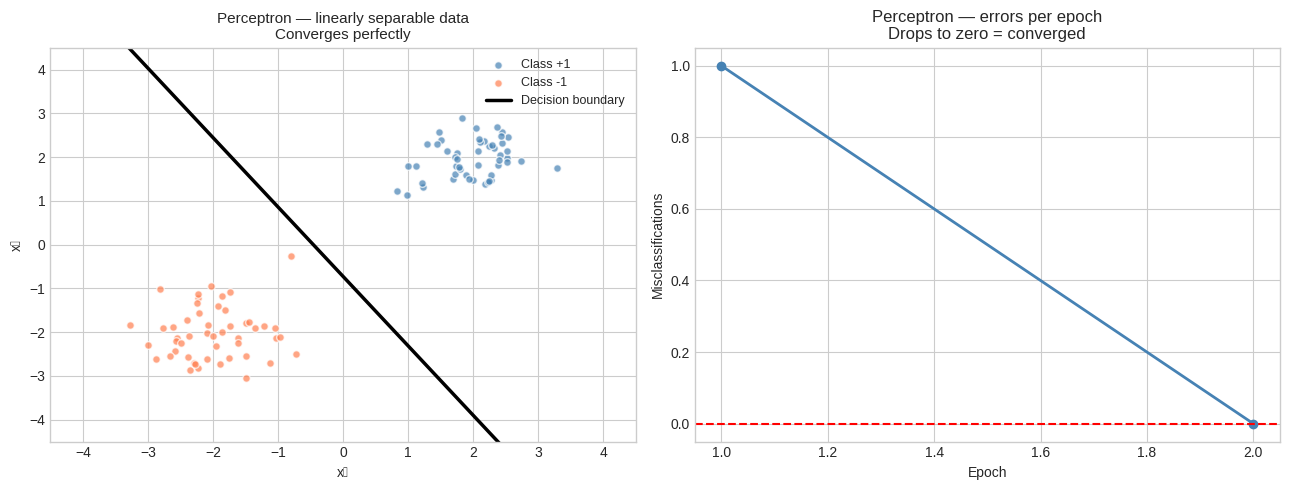

In [26]:
# ── Visualise decision boundary evolution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Final decision boundary
ax = axes[0]
ax.scatter(X_pos[:,0], X_pos[:,1], c='steelblue', s=30, alpha=0.7,
           edgecolors='white', label='Class +1')
ax.scatter(X_neg[:,0], X_neg[:,1], c='coral',     s=30, alpha=0.7,
           edgecolors='white', label='Class -1')

# Decision boundary: w[0]*x + w[1]*y + b = 0  =>  y = (-w[0]*x - b) / w[1]
x_range = np.linspace(-4, 4, 100)
if abs(perc.w[1]) > 1e-6:
    y_boundary = (-perc.w[0]*x_range - perc.b) / perc.w[1]
    ax.plot(x_range, y_boundary, 'k-', linewidth=2.5, label='Decision boundary')
ax.set_title('Perceptron — linearly separable data\nConverges perfectly', fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)

# Errors per epoch
axes[1].plot(range(1, len(perc.history)+1), perc.history,
             'o-', color='steelblue', linewidth=2, markersize=6)
axes[1].set_title('Perceptron — errors per epoch\nDrops to zero = converged')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Misclassifications')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()


## 3. Why One Layer Is Not Enough — The XOR Problem

In 1969, Minsky & Papert proved that the Perceptron cannot solve XOR — a problem that is not linearly separable. This finding nearly killed neural network research for a decade.

### XOR truth table

| $x_1$ | $x_2$ | XOR |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

**Why a single line cannot separate XOR:** The positive class (01, 10) and negative class (00, 11) cannot be divided by any single straight line in 2D space.

**The solution:** Add a hidden layer. With two hidden neurons, we can construct a representation where XOR becomes linearly separable. The hidden layer transforms the input space.

### Geometric interpretation

The first hidden layer **folds** the input space. Each neuron creates a new hyperplane. The combination of hyperplanes can carve out any region. This is why deep networks can approximate any continuous function.


Training Perceptron on XOR:
  Did not converge in 50 epochs
  Predictions: [0. 0. 0. 0.]
  True labels: [-1  1  1 -1]
  Accuracy: 0.00  (best possible with one layer)
  Converged at epoch 9
  Converged at epoch 6


/tmp/ipykernel_17008/3395390892.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/3395390892.py:49: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


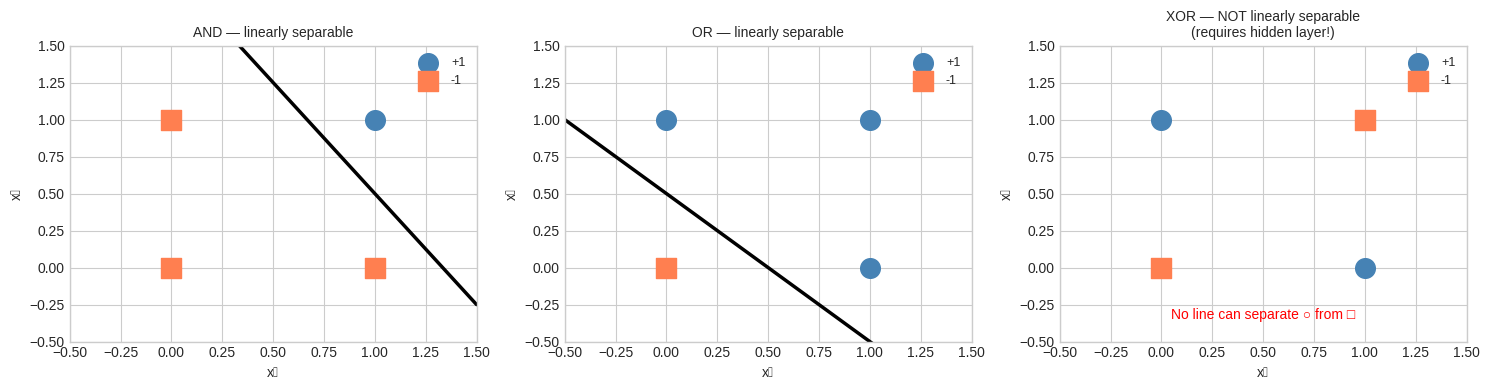

In [27]:
# ── Demonstrate: Perceptron fails on XOR ─────────────────────────────────────
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([-1, 1, 1, -1])  # XOR in {-1, +1}

perc_xor = Perceptron(n_features=2, lr=0.1, max_iter=50)
print('Training Perceptron on XOR:')
converged = perc_xor.fit(X_xor, y_xor)

preds = perc_xor.predict(X_xor)
print(f'  Predictions: {preds}')
print(f'  True labels: {y_xor}')
print(f'  Accuracy: {(preds == y_xor).mean():.2f}  (best possible with one layer)')

# Visualise why XOR is not linearly separable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, title, X_plot, y_plot in [
    (axes[0], 'AND — linearly separable',
     np.array([[0,0],[0,1],[1,0],[1,1]], float),
     np.array([-1,-1,-1,1])),
    (axes[1], 'OR — linearly separable',
     np.array([[0,0],[0,1],[1,0],[1,1]], float),
     np.array([-1,1,1,1])),
    (axes[2], 'XOR — NOT linearly separable\n(requires hidden layer!)',
     X_xor, y_xor),
]:
    mask_pos = y_plot == 1
    ax.scatter(X_plot[mask_pos,0],  X_plot[mask_pos,1],
               c='steelblue', s=200, marker='o', zorder=5, label='+1')
    ax.scatter(X_plot[~mask_pos,0], X_plot[~mask_pos,1],
               c='coral', s=200, marker='s', zorder=5, label='-1')

    if 'XOR' not in title:
        # Fit and draw boundary
        p = Perceptron(2, max_iter=100); p.fit(X_plot, y_plot)
        if abs(p.w[1]) > 1e-6:
            xr = np.linspace(-0.5, 1.5, 100)
            yr = (-p.w[0]*xr - p.b) / p.w[1]
            ax.plot(xr, yr, 'k-', linewidth=2.5)
    else:
        ax.text(0.5, -0.35, 'No line can separate ○ from □',
                ha='center', fontsize=10, color='red')

    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.tight_layout()
plt.show()


## 4. Multi-Layer Perceptron — Math Intuition

An MLP with $L$ layers applies the following transformation repeatedly:

$$\mathbf{z}^{(l)} = W^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{a}^{(l)} = f^{(l)}(\mathbf{z}^{(l)})$$

with $\mathbf{a}^{(0)} = \mathbf{x}$ and output $\hat{y} = \mathbf{a}^{(L)}$.

### Why non-linearity is essential

Without activation functions, any stack of linear layers collapses to a single linear transformation:

$$W^{(2)}(W^{(1)}\mathbf{x} + \mathbf{b}^{(1)}) + \mathbf{b}^{(2)} = (W^{(2)}W^{(1)})\mathbf{x} + (W^{(2)}\mathbf{b}^{(1)} + \mathbf{b}^{(2)}) = W'\mathbf{x} + \mathbf{b}'$$

Two linear layers = one linear layer. **Depth only helps if you add non-linearity.**

### Solving XOR with 2 hidden neurons

A 2-layer network can solve XOR by:
1. First layer: learn to detect whether inputs differ (one neuron) and match (another)
2. Second layer: combine those features to output XOR

The weights that solve XOR:

$$W^{(1)} = \begin{pmatrix} 1 & 1 \\ 1 & 1 \end{pmatrix}, \quad \mathbf{b}^{(1)} = \begin{pmatrix} 0 \\ -1 \end{pmatrix}, \quad W^{(2)} = \begin{pmatrix} 1 & -2 \end{pmatrix}, \quad b^{(2)} = 0$$


=== Hand-designed weights that solve XOR ===
   Input      Hidden z1    Hidden a1    Output   True 
-------------------------------------------------------
   [0 0]      [ 0. -1.]     [0. 0.]      0.00    0     0   
   [0 1]       [1. 0.]      [1. 0.]      1.00    1     1   
   [1 0]       [1. 0.]      [1. 0.]      1.00    1     1   
   [1 1]       [2. 1.]      [2. 1.]      0.00    0     0   

ReLU hidden layer transforms input space so XOR becomes linearly separable!


/tmp/ipykernel_17008/2788841133.py:52: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_17008/2788841133.py:52: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


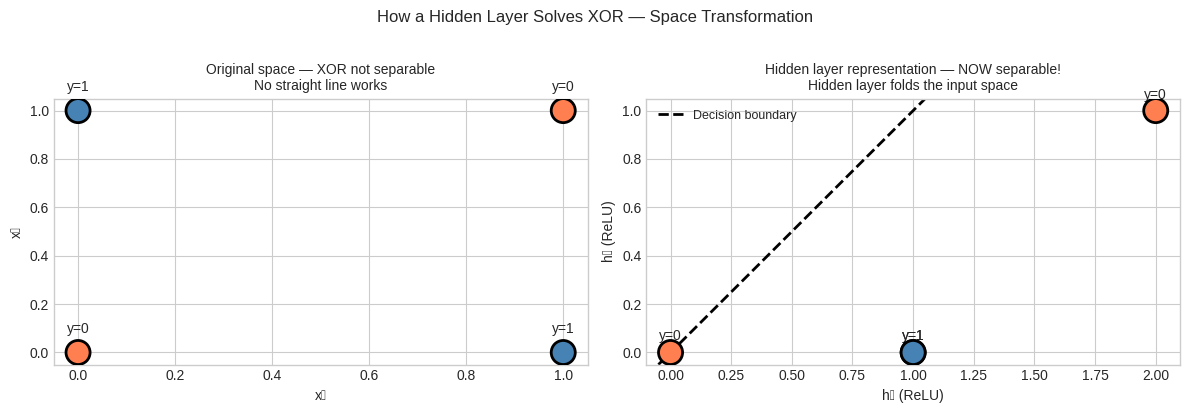

In [28]:
# ── Manually verify the weights that solve XOR ───────────────────────────────
print('=== Hand-designed weights that solve XOR ===')

def relu(x): return np.maximum(0, x)

W1 = np.array([[1., 1.], [1., 1.]])
b1 = np.array([0., -1.])
W2 = np.array([[1., -2.]])
b2 = np.array([0.])

X_xor_pos = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor_pos  = np.array([0, 1, 1, 0])   # standard XOR labels

print(f'{'Input':^12} {"Hidden z1":^12} {"Hidden a1":^12} {"Output":^8} {"True":^6}')
print('-' * 55)
for x, y_true in zip(X_xor_pos, y_xor_pos):
    z1 = W1 @ x + b1
    a1 = relu(z1)
    z2 = W2 @ a1 + b2
    y_hat = int(z2[0] > 0.5)
    print(f'{str(x.astype(int)):^12} {str(z1.round(1)):^12} '
          f'{str(a1.round(1)):^12} {z2[0]:^8.2f} {y_hat:^4} {y_true:^6}')

print('\nReLU hidden layer transforms input space so XOR becomes linearly separable!')

# Show the transformed space
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original space
colors_xor = ['coral' if y == 0 else 'steelblue' for y in y_xor_pos]
axes[0].scatter(X_xor_pos[:,0], X_xor_pos[:,1],
                c=colors_xor, s=300, edgecolors='black', linewidth=2, zorder=5)
for x, y_t in zip(X_xor_pos, y_xor_pos):
    axes[0].text(x[0], x[1]+0.08, f'y={y_t}', ha='center', fontsize=10)
axes[0].set_title('Original space — XOR not separable\nNo straight line works', fontsize=10)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')

# Hidden (transformed) space
hidden_reps = np.array([relu(W1 @ x + b1) for x in X_xor_pos])
axes[1].scatter(hidden_reps[:,0], hidden_reps[:,1],
                c=colors_xor, s=300, edgecolors='black', linewidth=2, zorder=5)
for h, y_t in zip(hidden_reps, y_xor_pos):
    axes[1].text(h[0], h[1]+0.05, f'y={y_t}', ha='center', fontsize=10)
axes[1].axline((0, 0), slope=1, color='black', linestyle='--',
               linewidth=2, label='Decision boundary')
axes[1].set_title('Hidden layer representation — NOW separable!\n'
                   'Hidden layer folds the input space', fontsize=10)
axes[1].set_xlabel('h₁ (ReLU)'); axes[1].set_ylabel('h₂ (ReLU)')
axes[1].legend(fontsize=9)

plt.suptitle('How a Hidden Layer Solves XOR — Space Transformation', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 5. Code Layer 1 — NumPy from Scratch

Build a fully connected MLP with the exact matrix calculus from `00_math/matrix_calculus.ipynb`. Three-layer network: input → hidden → output.


In [29]:
class MLPNumPy:
    """
    Multi-layer Perceptron — pure NumPy.
    Architecture: input(n_in) -> hidden(n_h) -> output(n_out)
    Activation: ReLU for hidden, sigmoid for output (binary classification)

    Forward:   z1 = W1 @ x + b1,  a1 = relu(z1)
               z2 = W2 @ a1 + b2, a2 = sigmoid(z2)  <- output probability

    Loss (binary CE): L = -[y log(a2) + (1-y) log(1-a2)]

    Backward (chain rule — see 00_math/matrix_calculus.ipynb):
    dL/dz2  = a2 - y                        (combined sigmoid+BCE gradient)
    dL/dW2  = dL/dz2 @ a1^T
    dL/dz1  = (W2^T @ dL/dz2) * relu'(z1)
    dL/dW1  = dL/dz1 @ x^T
    """

    def __init__(self, n_in, n_h, n_out, lr=0.01):
        # He initialisation
        self.W1 = np.random.randn(n_h, n_in)  * np.sqrt(2.0/n_in)
        self.b1 = np.zeros(n_h)
        self.W2 = np.random.randn(n_out, n_h) * np.sqrt(2.0/n_h)
        self.b2 = np.zeros(n_out)
        self.lr = lr

    def _relu(self, z):    return np.maximum(0, z)
    def _sigmoid(self, z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.X  = X                          # cache for backward
        self.z1 = X  @ self.W1.T + self.b1  # (batch, n_h)
        self.a1 = self._relu(self.z1)        # (batch, n_h)
        self.z2 = self.a1 @ self.W2.T + self.b2  # (batch, n_out)
        self.a2 = self._sigmoid(self.z2)     # (batch, n_out)  — output probability
        return self.a2

    def loss(self, y):
        eps = 1e-12
        return -np.mean(y*np.log(self.a2+eps) + (1-y)*np.log(1-self.a2+eps))

    def backward(self, y):
        m = len(y)
        # Output layer: combined sigmoid + BCE gradient = a2 - y
        dz2 = (self.a2 - y) / m               # (batch, n_out)
        dW2 = dz2.T @ self.a1                  # (n_out, n_h)
        db2 = dz2.sum(axis=0)                  # (n_out,)
        # Hidden layer: backprop through ReLU
        da1 = dz2 @ self.W2                    # (batch, n_h)
        dz1 = da1 * (self.z1 > 0)             # ReLU derivative
        dW1 = dz1.T @ self.X                   # (n_h, n_in)
        db1 = dz1.sum(axis=0)                  # (n_h,)
        # Gradient descent update
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=1000, verbose=True):
        losses = []
        for ep in range(epochs):
            self.forward(X)
            l = self.loss(y)
            losses.append(l)
            self.backward(y)
            if verbose and ep % 200 == 0:
                preds = (self.a2 > 0.5).astype(int)
                acc   = (preds == y).mean()
                print(f'  Epoch {ep:4d}  loss={l:.4f}  acc={acc:.4f}')
        return losses

# Train on XOR
np.random.seed(42)
X_xor_arr = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor_arr = np.array([[0],[1],[1],[0]], dtype=float)

mlp_np = MLPNumPy(n_in=2, n_h=4, n_out=1, lr=0.5)
print('Training MLPNumPy on XOR:')
losses_np = mlp_np.fit(X_xor_arr, y_xor_arr, epochs=1001)

preds_np = (mlp_np.forward(X_xor_arr) > 0.5).astype(int)
print(f'\nFinal predictions: {preds_np.ravel()}')
print(f'True labels:       {y_xor_arr.ravel().astype(int)}')
print(f'Accuracy: {(preds_np == y_xor_arr).mean():.4f}')


Training MLPNumPy on XOR:
  Epoch    0  loss=0.7083  acc=0.7500
  Epoch  200  loss=0.0510  acc=1.0000
  Epoch  400  loss=0.0162  acc=1.0000
  Epoch  600  loss=0.0091  acc=1.0000
  Epoch  800  loss=0.0062  acc=1.0000
  Epoch 1000  loss=0.0047  acc=1.0000

Final predictions: [0 1 1 0]
True labels:       [0 1 1 0]
Accuracy: 1.0000


## 6. Code Layer 2 — Raw PyTorch Tensors

Same network, same math — but now we let autograd handle the backward pass. We still manage parameters manually (no `nn.Module`). This shows exactly what `nn.Module` adds.


In [30]:
# ── Same MLP, raw PyTorch tensors, manual parameter update ───────────────────
import torch
import torch.nn.functional as F

torch.manual_seed(42)

X_t = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_t = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# Network size
n_in, n_h, n_out = 2, 4, 1

# Initialize parameters (correct leaf tensors)
W1_t = torch.randn(n_h, n_in) * (2.0/n_in)**0.5
W1_t.requires_grad_()

b1_t = torch.zeros(n_h, requires_grad=True)

W2_t = torch.randn(n_out, n_h) * (2.0/n_h)**0.5
W2_t.requires_grad_()

b2_t = torch.zeros(n_out, requires_grad=True)

params = [W1_t, b1_t, W2_t, b2_t]

lr_raw = 0.5
losses_raw = []

for epoch in range(1001):

    # Forward pass
    z1 = X_t @ W1_t.T + b1_t
    a1 = F.relu(z1)

    z2 = a1 @ W2_t.T + b2_t
    a2 = torch.sigmoid(z2)

    loss = F.binary_cross_entropy(a2, y_t)

    # Reset gradients
    for p in params:
        if p.grad is not None:
            p.grad.zero_()

    # Backprop
    loss.backward()

    # Manual Gradient Descent
    with torch.no_grad():
        for p in params:
            if p.grad is None:
                continue
            p -= lr_raw * p.grad

    losses_raw.append(loss.item())

    if epoch % 200 == 0:
        preds = (a2 > 0.5).float()
        acc = (preds == y_t).float().mean().item()
        print(f'Epoch {epoch:4d} | loss={loss.item():.4f} | acc={acc:.4f}')

# Final prediction
with torch.no_grad():
    a2_final = torch.sigmoid(F.relu(X_t @ W1_t.T + b1_t) @ W2_t.T + b2_t)
    preds_raw = (a2_final > 0.5).int()

print("\nFinal predictions:", preds_raw.ravel().tolist())

Epoch    0 | loss=0.7444 | acc=0.7500
Epoch  200 | loss=0.0380 | acc=1.0000
Epoch  400 | loss=0.0117 | acc=1.0000
Epoch  600 | loss=0.0067 | acc=1.0000
Epoch  800 | loss=0.0047 | acc=1.0000
Epoch 1000 | loss=0.0036 | acc=1.0000

Final predictions: [0, 1, 1, 0]


## 7. Code Layer 3 — nn.Module API

Same network, same math — now using the full PyTorch API. This is how you write production code.


  Epoch    0  loss=0.8065  acc=0.5000
  Epoch  200  loss=0.0029  acc=1.0000
  Epoch  400  loss=0.0010  acc=1.0000
  Epoch  600  loss=0.0006  acc=1.0000
  Epoch  800  loss=0.0003  acc=1.0000
  Epoch 1000  loss=0.0002  acc=1.0000


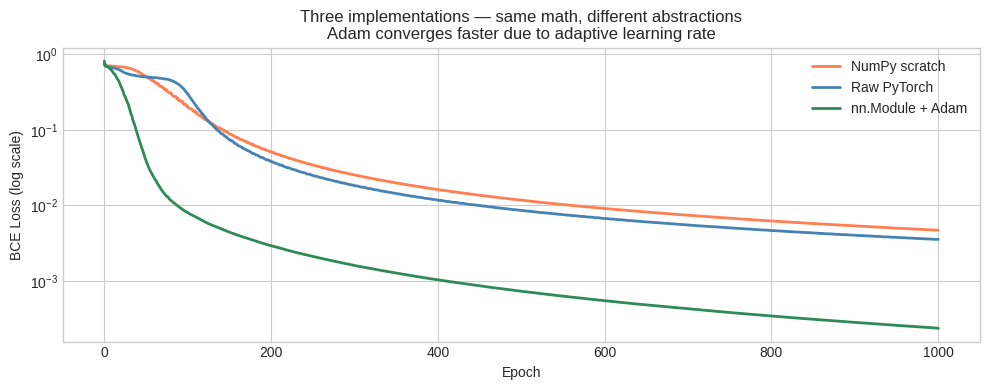

In [31]:
# ── Same MLP, nn.Module, nn.BCEWithLogitsLoss, optim.Adam ────────────────────
class MLPModule(nn.Module):
    def __init__(self, n_in, n_h, n_out):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_h)
        self.fc2 = nn.Linear(n_h, n_out)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))
        # Note: returns logits, NOT sigmoid output
        # Use BCEWithLogitsLoss which applies sigmoid internally (more stable)

torch.manual_seed(42)
model_mod = MLPModule(2, 4, 1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_mod.parameters(), lr=0.1)

X_dev = X_t.to(device)
y_dev = y_t.to(device)

losses_mod = []
for epoch in range(1001):
    model_mod.train()
    optimizer.zero_grad()                    # 1. zero grads
    logits = model_mod(X_dev)               # 2. forward
    loss   = criterion(logits, y_dev)        # 3. loss (sigmoid inside)
    loss.backward()                          # 4. backward
    optimizer.step()                         # 5. update
    losses_mod.append(loss.item())
    if epoch % 200 == 0:
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5).float()
            acc   = (preds == y_dev).float().mean().item()
        print(f'  Epoch {epoch:4d}  loss={loss.item():.4f}  acc={acc:.4f}')

# Compare all three implementations
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(losses_np,  color='coral',     linewidth=2, label='NumPy scratch')
ax.semilogy(losses_raw, color='steelblue', linewidth=2, label='Raw PyTorch')
ax.semilogy(losses_mod, color='seagreen',  linewidth=2, label='nn.Module + Adam')
ax.set_title('Three implementations — same math, different abstractions\n'
             'Adam converges faster due to adaptive learning rate')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss (log scale)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Training Dashboard

Final val accuracy: 0.9688


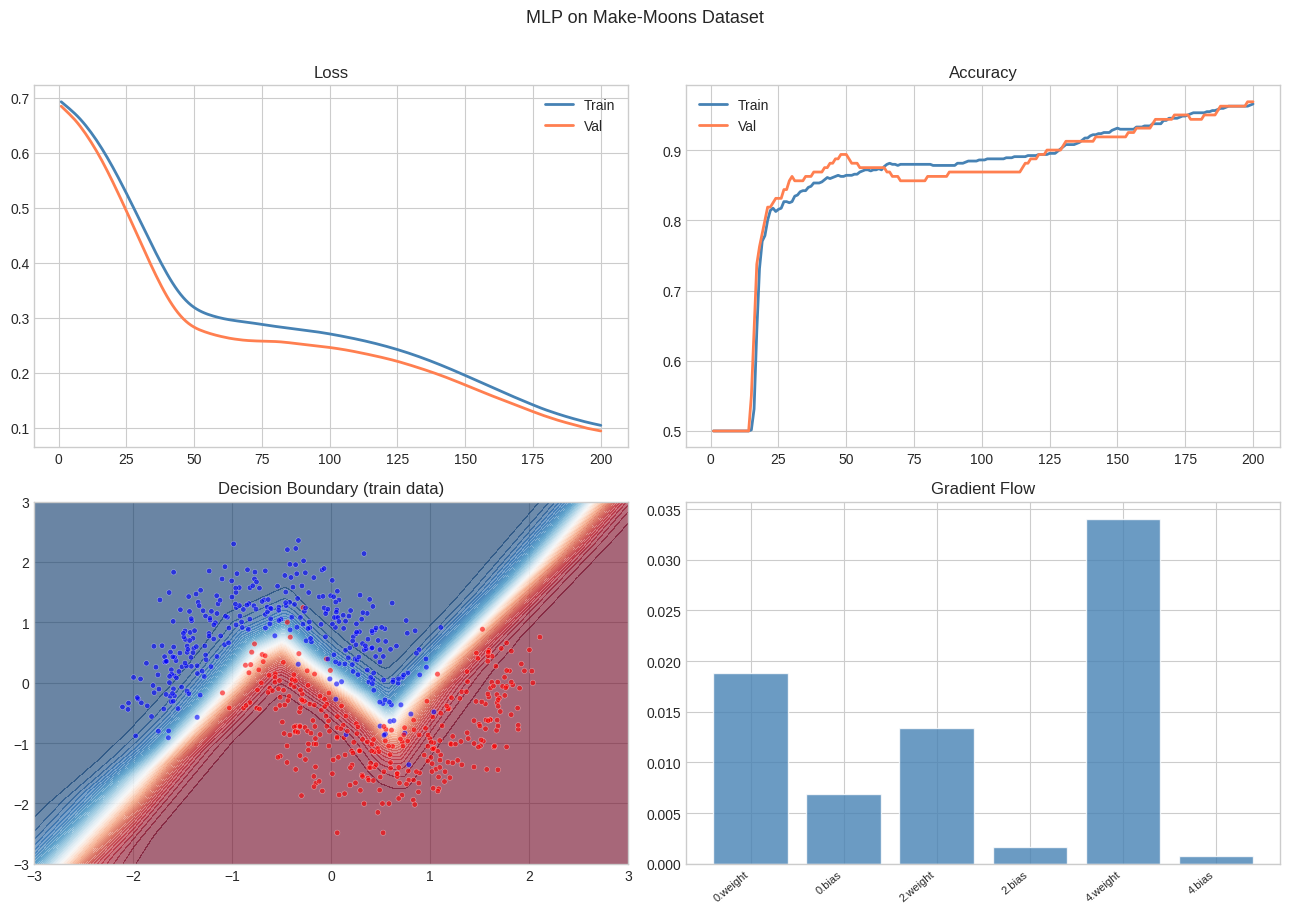

In [32]:
# ── Full training run on a real dataset with the 4-panel dashboard ───────────
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_m, y_m = make_moons(n_samples=800, noise=0.2, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

sc = StandardScaler()
X_tr = sc.fit_transform(X_tr); X_va = sc.transform(X_va)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1).to(device)
y_va_t = torch.tensor(y_va, dtype=torch.float32).unsqueeze(1).to(device)

torch.manual_seed(42)
model_moon = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 1)
).to(device)

criterion_m = nn.BCEWithLogitsLoss()
optimizer_m = optim.Adam(model_moon.parameters(), lr=5e-3)

hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}

for epoch in range(200):
    model_moon.train()
    optimizer_m.zero_grad()
    out = model_moon(X_tr_t)
    l   = criterion_m(out, y_tr_t)
    l.backward()
    optimizer_m.step()

    model_moon.eval()
    with torch.no_grad():
        vl  = criterion_m(model_moon(X_va_t), y_va_t).item()
        tl  = l.item()
        tac = ((torch.sigmoid(out) > 0.5) == y_tr_t).float().mean().item()
        vac = ((torch.sigmoid(model_moon(X_va_t)) > 0.5) == y_va_t).float().mean().item()

    hist['train_loss'].append(tl); hist['val_loss'].append(vl)
    hist['train_acc'].append(tac); hist['val_acc'].append(vac)
    hist['lr'].append(optimizer_m.param_groups[0]['lr'])

print(f'Final val accuracy: {hist["val_acc"][-1]:.4f}')

# 4-panel dashboard
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ep = range(1, 201)

axes[0,0].plot(ep, hist['train_loss'], color='steelblue', lw=2, label='Train')
axes[0,0].plot(ep, hist['val_loss'],   color='coral',     lw=2, label='Val')
axes[0,0].set_title('Loss'); axes[0,0].legend()

axes[0,1].plot(ep, hist['train_acc'], color='steelblue', lw=2, label='Train')
axes[0,1].plot(ep, hist['val_acc'],   color='coral',     lw=2, label='Val')
axes[0,1].set_title('Accuracy'); axes[0,1].legend()

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-3,3,150), np.linspace(-3,3,150))
grid   = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
with torch.no_grad():
    zz = torch.sigmoid(model_moon(grid)).cpu().numpy().reshape(xx.shape)
axes[1,0].contourf(xx, yy, zz, levels=50, cmap='RdBu_r', alpha=0.6)
axes[1,0].scatter(X_tr[:,0], X_tr[:,1], c=y_tr, cmap='bwr',
                  s=15, alpha=0.6, edgecolors='white', linewidth=0.3)
axes[1,0].set_title('Decision Boundary (train data)')

# Gradient norms
model_moon.train()
optimizer_m.zero_grad()
criterion_m(model_moon(X_tr_t), y_tr_t).backward()
names_gn = [n for n, p in model_moon.named_parameters() if p.grad is not None]
norms_gn = [p.grad.norm().item() for n, p in model_moon.named_parameters() if p.grad is not None]
axes[1,1].bar(range(len(names_gn)), norms_gn, color='steelblue', alpha=0.8, edgecolor='white')
axes[1,1].set_xticks(range(len(names_gn)))
axes[1,1].set_xticklabels(names_gn, rotation=40, ha='right', fontsize=8)
axes[1,1].set_title('Gradient Flow')

plt.suptitle('MLP on Make-Moons Dataset', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 9. Paper → Code: Universal Approximation Theorem

**Paper:** Cybenko (1989), Hornik (1991)

**Theorem:** A feedforward network with a single hidden layer containing a finite number of neurons can approximate any continuous function on a compact subset of $\mathbb{R}^n$ to arbitrary precision.

**What it says:** One hidden layer is theoretically sufficient. Given enough hidden neurons, an MLP can fit any continuous function.

**What it does NOT say:**
- It does not say how many neurons are needed (could be exponential in input dimension)
- It does not say anything about learning efficiency or generalisation
- It does not say shallow networks are as efficient as deep networks

**Why depth still matters:** Deep networks can represent certain functions exponentially more efficiently than shallow networks. A function requiring $O(2^n)$ neurons in one layer may only need $O(n)$ neurons per layer with $O(n)$ layers.

**Code experiment:** Approximate a non-trivial function with increasing hidden sizes and compare shallow (1 hidden layer) vs deep (3 hidden layers) networks.


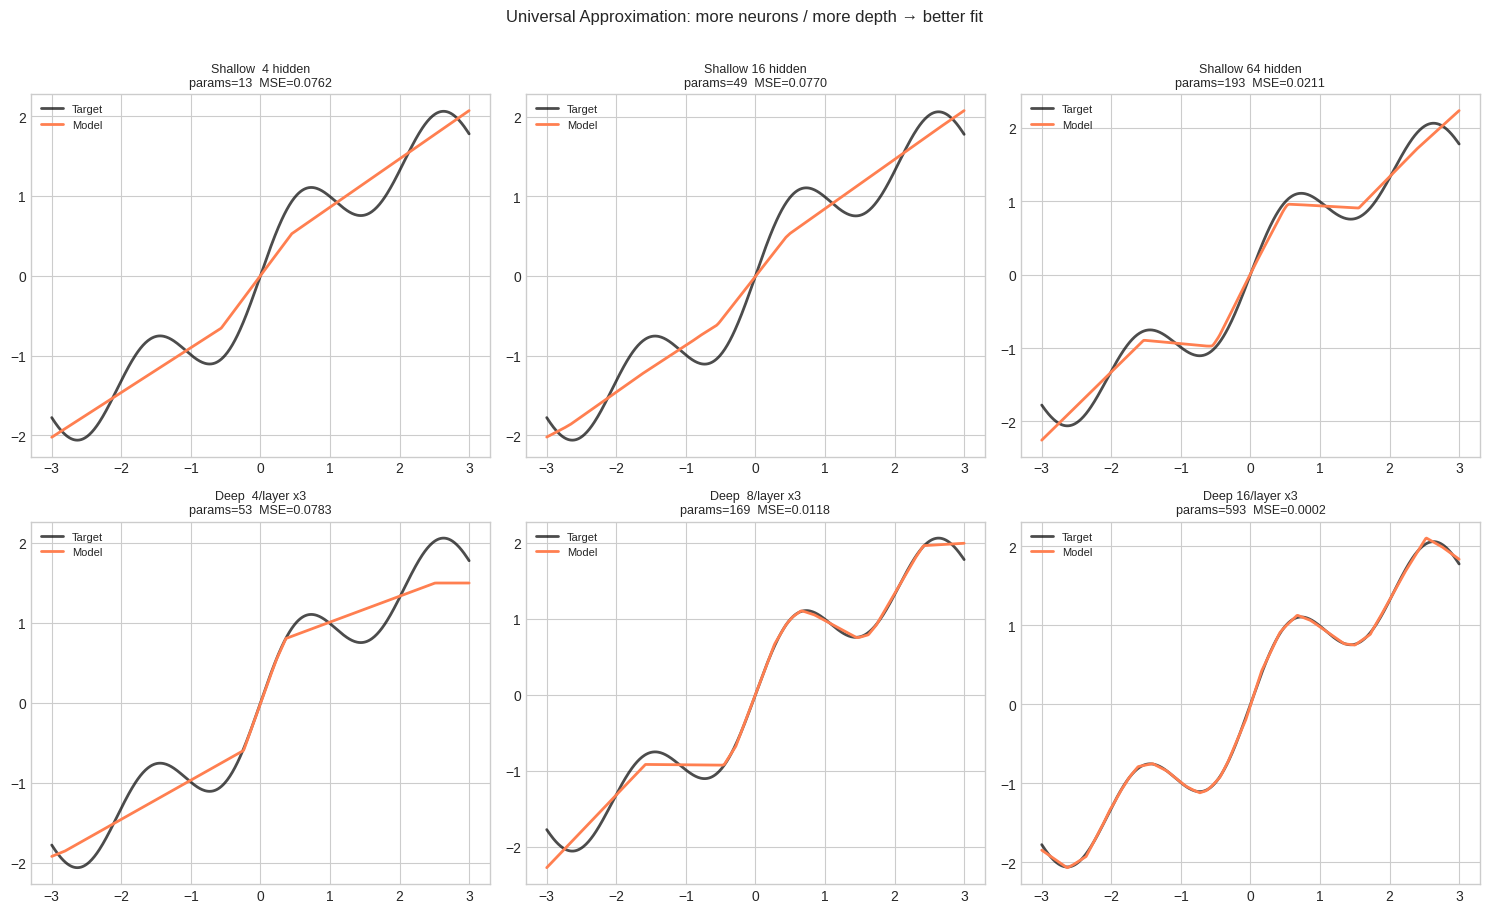

In [33]:
# ── Demonstrate UAT: fit any continuous function ─────────────────────────────
torch.manual_seed(0)

# Target function: complex non-linear
x_uat = np.linspace(-3, 3, 500)
y_uat = np.sin(2*x_uat) * np.cos(x_uat) + 0.5*x_uat

X_uat = torch.tensor(x_uat.reshape(-1,1), dtype=torch.float32)
Y_uat = torch.tensor(y_uat.reshape(-1,1), dtype=torch.float32)

def make_shallow(n_hidden):
    return nn.Sequential(nn.Linear(1, n_hidden), nn.ReLU(), nn.Linear(n_hidden, 1))

def make_deep(n_hidden):
    return nn.Sequential(
        nn.Linear(1, n_hidden),  nn.ReLU(),
        nn.Linear(n_hidden, n_hidden), nn.ReLU(),
        nn.Linear(n_hidden, n_hidden), nn.ReLU(),
        nn.Linear(n_hidden, 1)
    )

def train_model(model, X, Y, epochs=2000, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        F.mse_loss(model(X), Y).backward()
        opt.step()
    with torch.no_grad():
        return model(X).numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

configs = [
    (make_shallow(4),   'Shallow  4 hidden'), (make_shallow(16),  'Shallow 16 hidden'),
    (make_shallow(64),  'Shallow 64 hidden'), (make_deep(4),      'Deep  4/layer x3'),
    (make_deep(8),      'Deep  8/layer x3'), (make_deep(16),     'Deep 16/layer x3'),
]

for ax, (model_uat, title) in zip(axes.ravel(), configs):
    torch.manual_seed(1)
    y_pred_uat = train_model(model_uat, X_uat, Y_uat)
    mse = np.mean((y_pred_uat.ravel() - y_uat)**2)
    n_params = sum(p.numel() for p in model_uat.parameters())

    ax.plot(x_uat, y_uat, 'k-', linewidth=2, alpha=0.7, label='Target')
    ax.plot(x_uat, y_pred_uat, color='coral', linewidth=2, label='Model')
    ax.set_title(f'{title}\nparams={n_params}  MSE={mse:.4f}', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Universal Approximation: more neurons / more depth → better fit',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 10. Debugging Section

In [34]:
# ── Reproduce common MLP failure modes ───────────────────────────────────────
print('=== Failure Mode 1: Linear activation — no non-linearity ===')
print()

torch.manual_seed(42)

class BadLinearMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        return self.fc2(self.fc1(x))  # BUG: no activation between layers!

class GoodMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))  # correct: ReLU between layers

def quick_train(model, X, y, epochs=300):
    opt  = optim.Adam(model.parameters(), lr=1e-2)
    crit = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        opt.zero_grad(); crit(model(X), y).backward(); opt.step()
    with torch.no_grad():
        acc = ((torch.sigmoid(model(X))>0.5).float()==y).float().mean().item()
    return acc

# Test on moons (non-linear problem)
acc_bad  = quick_train(BadLinearMLP(),  X_tr_t[:, :2], y_tr_t)
acc_good = quick_train(GoodMLP(),       X_tr_t[:, :2], y_tr_t)
print(f'No activation (linear only):  acc = {acc_bad:.4f}  <- stuck at linear boundary')
print(f'With ReLU activation:         acc = {acc_good:.4f}')
print('Two linear layers = one linear layer — depth is useless without non-linearity')


=== Failure Mode 1: Linear activation — no non-linearity ===

No activation (linear only):  acc = 0.8750  <- stuck at linear boundary
With ReLU activation:         acc = 0.9594
Two linear layers = one linear layer — depth is useless without non-linearity


In [35]:
# ── Failure Mode 2: Wrong output activation for loss function ─────────────────
print('=== Failure Mode 2: Applying sigmoid BEFORE BCEWithLogitsLoss ===')
print()

torch.manual_seed(0)
X_dbg = torch.randn(100, 4)
y_dbg = torch.randint(0, 2, (100, 1)).float()
W_dbg = nn.Linear(4, 1)

# WRONG: sigmoid in model + BCEWithLogitsLoss = double sigmoid!
logits_wrong = torch.sigmoid(W_dbg(X_dbg))
loss_wrong   = nn.BCEWithLogitsLoss()(logits_wrong, y_dbg)

# CORRECT option 1: logits + BCEWithLogitsLoss
logits_right = W_dbg(X_dbg)
loss_right1  = nn.BCEWithLogitsLoss()(logits_right, y_dbg)

# CORRECT option 2: sigmoid output + BCELoss
probs_right  = torch.sigmoid(W_dbg(X_dbg))
loss_right2  = nn.BCELoss()(probs_right, y_dbg)

print(f'WRONG (sigmoid + BCEWithLogitsLoss):       loss = {loss_wrong.item():.4f}')
print(f'CORRECT (logits + BCEWithLogitsLoss):      loss = {loss_right1.item():.4f}')
print(f'CORRECT (sigmoid output + BCELoss):        loss = {loss_right2.item():.4f}')
print()
print('BCEWithLogitsLoss = sigmoid + BCE in one numerically stable operation')
print('NEVER apply sigmoid to output AND use BCEWithLogitsLoss')


=== Failure Mode 2: Applying sigmoid BEFORE BCEWithLogitsLoss ===

WRONG (sigmoid + BCEWithLogitsLoss):       loss = 0.7371
CORRECT (logits + BCEWithLogitsLoss):      loss = 0.7564
CORRECT (sigmoid output + BCELoss):        loss = 0.7564

BCEWithLogitsLoss = sigmoid + BCE in one numerically stable operation
NEVER apply sigmoid to output AND use BCEWithLogitsLoss


In [36]:
# ── Failure Mode 3: Using wrong shapes for batched inference ─────────────────
print('=== Failure Mode 3: Shape mismatch in batched vs single-sample inference ===')
print()

model_shape = nn.Linear(4, 2)

# Single sample — must unsqueeze!
x_single = torch.randn(4)           # shape (4,)
try:
    out = model_shape(x_single)     # this WORKS in PyTorch (auto-batch)
    print(f'Single sample (4,):     output shape = {out.shape}  (ok)')
except Exception as e:
    print(f'Error: {e}')

# But this breaks downstream code expecting (batch, out)
x_single_batched = x_single.unsqueeze(0)  # shape (1, 4)
out_batched = model_shape(x_single_batched)
print(f'Single sample (1,4):    output shape = {out_batched.shape}  (explicit batch dim)')

# Batch of samples
x_batch = torch.randn(8, 4)         # shape (8, 4)
out_batch = model_shape(x_batch)
print(f'Batch of 8 (8,4):       output shape = {out_batch.shape}')

print('\nRule: Always pass inputs with explicit batch dimension (B, features)')
print('Use x.unsqueeze(0) for single-sample inference')


=== Failure Mode 3: Shape mismatch in batched vs single-sample inference ===

Single sample (4,):     output shape = torch.Size([2])  (ok)
Single sample (1,4):    output shape = torch.Size([1, 2])  (explicit batch dim)
Batch of 8 (8,4):       output shape = torch.Size([8, 2])

Rule: Always pass inputs with explicit batch dimension (B, features)
Use x.unsqueeze(0) for single-sample inference


## 11. Exercises

**Exercise 1:** Extend `MLPNumPy` to support **arbitrary depth** — accept a `layer_dims` list like `[2, 8, 8, 4, 1]` and build the correct number of layers. Implement the general forward and backward passes using Python loops. Verify on XOR and make_moons.


In [37]:
# Your code here


In [38]:
# Solution
class DeepMLPNumPy:
    def __init__(self, layer_dims, lr=0.01):
        self.lr  = lr
        self.Ws  = []
        self.bs  = []
        for i in range(len(layer_dims)-1):
            n_in_l, n_out_l = layer_dims[i], layer_dims[i+1]
            self.Ws.append(np.random.randn(n_out_l, n_in_l) * np.sqrt(2.0/n_in_l))
            self.bs.append(np.zeros(n_out_l))

    def forward(self, X):
        self.cache = {'A0': X}
        A = X
        for l, (W, b) in enumerate(zip(self.Ws, self.bs)):
            Z = A @ W.T + b
            self.cache[f'Z{l+1}'] = Z
            # Hidden layers: ReLU; output layer: sigmoid
            A = np.maximum(0, Z) if l < len(self.Ws)-1 else 1/(1+np.exp(-Z))
            self.cache[f'A{l+1}'] = A
        return A

    def fit(self, X, y, epochs=500):
        L = len(self.Ws)
        losses = []
        for ep in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y*np.log(out+1e-12)+(1-y)*np.log(1-out+1e-12))
            losses.append(loss)
            m = len(X)
            Delta = (out - y) / m   # output delta
            for l in range(L-1, -1, -1):
                dW = Delta.T @ self.cache[f'A{l}']
                db = Delta.sum(axis=0)
                self.Ws[l] -= self.lr * dW
                self.bs[l] -= self.lr * db
                if l > 0:
                    dA = Delta @ self.Ws[l]
                    Delta = dA * (self.cache[f'Z{l}'] > 0)  # ReLU backward
        return losses

np.random.seed(42)
deep_np = DeepMLPNumPy([2, 8, 8, 1], lr=0.1)
losses_deep = deep_np.fit(X_xor_arr, y_xor_arr, epochs=2000)
preds_deep = (deep_np.forward(X_xor_arr) > 0.5).astype(int)
print(f'DeepMLPNumPy on XOR: accuracy = {(preds_deep == y_xor_arr).mean():.4f}')


DeepMLPNumPy on XOR: accuracy = 1.0000


**Exercise 2:** Visualise **what each hidden neuron has learned** in the trained XOR network. For the `MLPModule` trained on XOR, plot:
- The weight vector of each hidden neuron as a 2D direction arrow
- The activation value of each neuron for all 4 XOR inputs as a heatmap
- The decision boundary of each individual neuron (before the output layer)


In [39]:
# Your code here


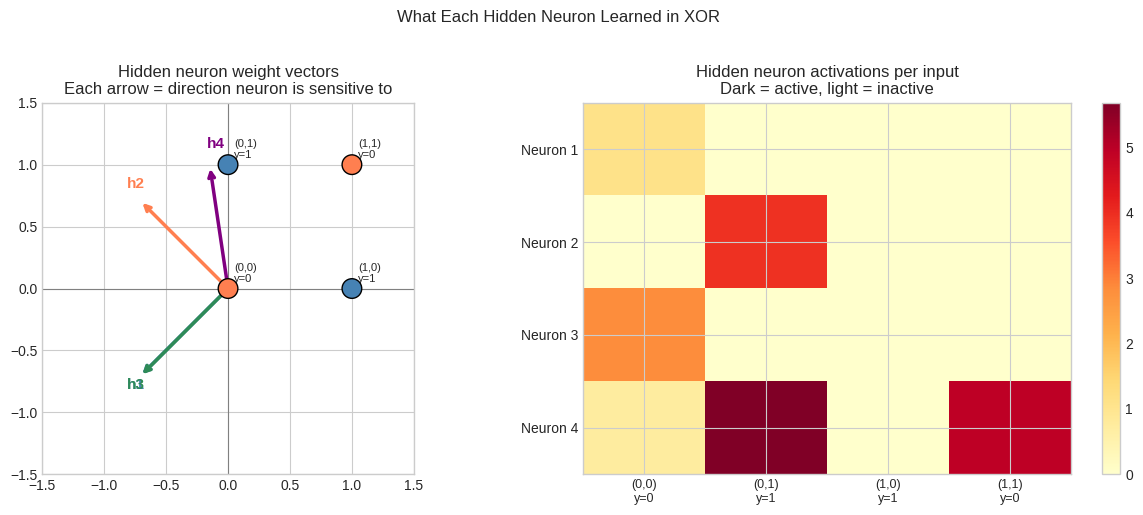

In [40]:
# Solution
model_mod.eval()

# Get weights of hidden layer
W1_vis = model_mod.fc1.weight.detach().numpy()  # (n_h, 2)
b1_vis = model_mod.fc1.bias.detach().numpy()    # (n_h,)

# Get activations for all XOR inputs
with torch.no_grad():
    X_vis_t  = torch.tensor(X_xor_arr, dtype=torch.float32)
    h_vis    = F.relu(model_mod.fc1(X_vis_t)).numpy()  # (4, n_h)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Weight vectors as arrows
ax = axes[0]
colors_h = ['steelblue','coral','seagreen','purple']
for idx, (w, color) in enumerate(zip(W1_vis[:4], colors_h)):
    norm = np.linalg.norm(w)
    ax.annotate('', xy=w/norm, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(w[0]/norm*1.15, w[1]/norm*1.15,
            f'h{idx+1}', color=color, fontsize=11, fontweight='bold')
ax.scatter(*zip(*X_xor_arr), c=['coral','steelblue','steelblue','coral'],
           s=200, edgecolors='black', zorder=5)
for pt, lbl in zip(X_xor_arr, ['(0,0)\ny=0','(0,1)\ny=1','(1,0)\ny=1','(1,1)\ny=0']):
    ax.text(pt[0]+0.05, pt[1]+0.05, lbl, fontsize=8)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Hidden neuron weight vectors\nEach arrow = direction neuron is sensitive to')
ax.set_aspect('equal')

# Activation heatmap
im = axes[1].imshow(h_vis[:4, :4].T, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['(0,0)\ny=0','(0,1)\ny=1','(1,0)\ny=1','(1,1)\ny=0'], fontsize=9)
axes[1].set_yticks(range(min(4, h_vis.shape[1])))
axes[1].set_yticklabels([f'Neuron {i+1}' for i in range(min(4, h_vis.shape[1]))])
axes[1].set_title('Hidden neuron activations per input\nDark = active, light = inactive')

plt.suptitle('What Each Hidden Neuron Learned in XOR', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Exercise 3:** Build a **depth comparison experiment**. Train networks of depths 1, 2, 3, 4 (all with the same total parameter count ~500) on a noisy version of a target function. For each depth, record final train loss and test loss. Plot:
- Loss curves for each architecture
- A final train vs test scatter showing the bias-variance tradeoff

Does depth help generalisation on this task?


In [41]:
# Your code here


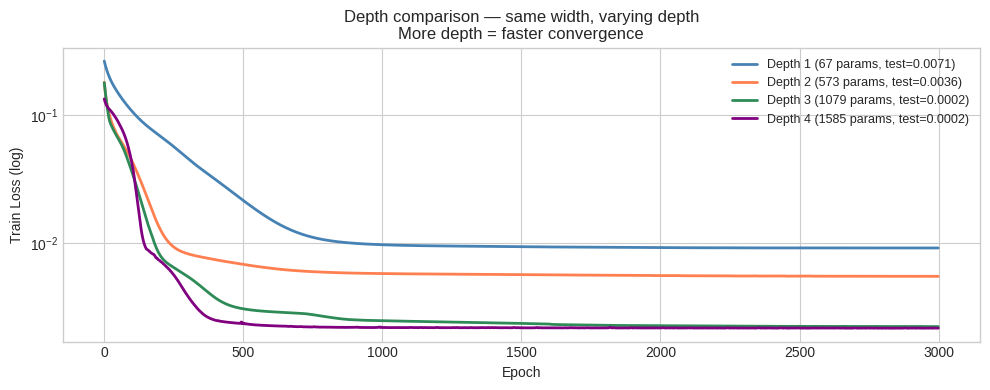

Depth      Train Loss    Test Loss        Gap   Params
1            0.009165     0.007062  -0.002103       67
2            0.005499     0.003631  -0.001868      573
3            0.002225     0.000159  -0.002067     1079
4            0.002164     0.000198  -0.001966     1585


In [42]:
# Solution
torch.manual_seed(42)

# Target: noisy sinc function
x_depth = torch.linspace(-4, 4, 500).reshape(-1, 1)
y_clean = torch.sinc(x_depth)
y_noisy = y_clean + 0.05 * torch.randn_like(y_clean)

# Architectures with ~same param count
def build_net(depth, n_hidden=22):
    layers = [nn.Linear(1, n_hidden), nn.ReLU()]
    for _ in range(depth - 1):
        layers += [nn.Linear(n_hidden, n_hidden), nn.ReLU()]
    layers += [nn.Linear(n_hidden, 1)]
    return nn.Sequential(*layers)

depths      = [1, 2, 3, 4]
results_dep = {}

fig, ax = plt.subplots(figsize=(10, 4))

colors_dep = ['steelblue', 'coral', 'seagreen', 'purple']
for d, color in zip(depths, colors_dep):
    torch.manual_seed(0)
    net = build_net(d)
    opt = optim.Adam(net.parameters(), lr=1e-3)
    n_p = sum(p.numel() for p in net.parameters())
    tr_losses = []
    for _ in range(3000):
        opt.zero_grad()
        l = F.mse_loss(net(x_depth), y_noisy)
        l.backward(); opt.step()
        tr_losses.append(l.item())
    with torch.no_grad():
        test_loss = F.mse_loss(net(x_depth), y_clean).item()
    results_dep[d] = (tr_losses[-1], test_loss, n_p)
    ax.semilogy(tr_losses, color=color, lw=2,
                label=f'Depth {d} ({n_p} params, test={test_loss:.4f})')

ax.set_title('Depth comparison — same width, varying depth\nMore depth = faster convergence')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss (log)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'{'Depth':<8} {'Train Loss':>12} {'Test Loss':>12} {'Gap':>10} {'Params':>8}')
for d, (trl, tel, np_) in results_dep.items():
    print(f'{d:<8} {trl:12.6f} {tel:12.6f} {tel-trl:10.6f} {np_:8d}')


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
